# MLP Optimisation

In [1]:
# Fibonacci using Recursion
import time
def fib(n):
  if n==1 or n==0:
    return 1
  else:
    return fib(n-1) + fib(n-2)

In [2]:
# T.C = O(2^n)
start = time.time()
fib(40)
print(time.time() - start)  # 23.380074501037598 seconds

21.509267807006836


In [3]:
# Fibonacci using Memoization
import time
def fib(n,dict):
  if n in dict:
    return dict[n]
  else:
    dict[n] = fib(n-1,dict) + fib(n-2,dict)
    return dict[n]

In [4]:
start = time.time()
dict = {0:1, 1:1}
fib(100,dict)
print(time.time() - start)

0.00020241737365722656


# Gradient Descent in Neural Networks

In [5]:
import numpy as np
import pandas as pd
import time

 ### Dataset Link keggle
 https://www.kaggle.com/code/dhirajbembade/social-network-ads?select=Social_Network_Ads.csv

In [6]:
df =pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
df.shape

(400, 5)

In [8]:
df = df[['Age','EstimatedSalary','Purchased']]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [9]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
# X,y

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [14]:
X_train.shape, X_test.shape

((320, 2), (80, 2))

In [15]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [16]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

### Which is Faster according to time (Given Same no. of Epochs)? -> Batch Gradient Descent will give faster result

In [18]:
#Batch Gradient Descent -> weight and bias will update only one time in each epoch
# so for 10 epoch it will update only 10 times
# model.compile(loss='binary_crossentropy',metrics=['accuracy'])
# start = time.time()
# history = model.fit(X_train, y_train, epochs=10, batch_size=320)
# print(time.time() - start)

In [19]:
#Stochastic Gradient Descent -> Gradient will update (no. of rows * no. of epochs)
# so for epochs=10, X_train.shape=320 which means (320 * 10 = 3200)
# model.compile(loss='binary_crossentropy',metrics=['accuracy'])
# start = time.time()
# history = model.fit(X_train, y_train, epochs=10, batch_size=1)
# print(time.time() - start)

## Which is Faster to Converge (Given Same no. of epochs)? -> Stochastic GD ( reaching best values of coeffients and intercepts)

In [20]:
X_scaled.shape

(400, 2)

In [21]:
#Batch Gradient Descent which will take more no. of epochs for optimised GD
# model.compile(loss='binary_crossentropy',metrics=['accuracy'])
# history = model.fit(X_scaled, y, epochs=10, batch_size=400, validation_split=0.2)

In [22]:
#Stochastic Gradient Descent Convergence is faster to reach Solution
# model.compile(loss='binary_crossentropy',metrics=['accuracy'])
# history = model.fit(X_scaled, y, epochs=10, batch_size=1, validation_split=0.2)

# Loss Decreased in Unstable way in Stochastic Gradient Descent

In [24]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled, y, epochs=500, batch_size=1, validation_split=0.2)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8392 - loss: 0.2841 - val_accuracy: 0.8750 - val_loss: 0.3628
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8862 - loss: 0.2688 - val_accuracy: 0.9500 - val_loss: 0.3132
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8958 - loss: 0.2609 - val_accuracy: 0.9500 - val_loss: 0.2990
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9152 - loss: 0.2019 - val_accuracy: 0.9750 - val_loss: 0.2686
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8441 - loss: 0.3247 - val_accuracy: 0.9750 - val_loss: 0.2438
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9129 - loss: 0.2262 - val_accuracy: 0.9750 - val_loss: 0.2314
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9038 - loss: 0.2069 - val_accuracy: 0.9750 - val_loss: 0.2153
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8928 - loss: 0.2669 - val_accu

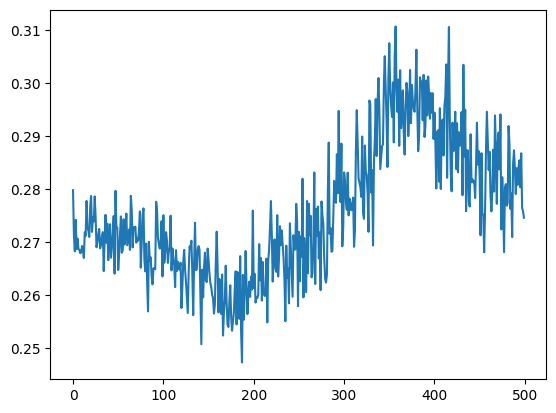

In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

# Loss Decreased in Stable way in Batch Gradient Descent

In [26]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled, y, epochs=500, batch_size=400, validation_split=0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9187 - loss: 0.2746 - val_accuracy: 0.9125 - val_loss: 0.2596
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9187 - loss: 0.2634 - val_accuracy: 0.9000 - val_loss: 0.2709
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9187 - loss: 0.2570 - val_accuracy: 0.8750 - val_loss: 0.2759
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9219 - loss: 0.2523 - val_accuracy: 0.8750 - val_loss: 0.2792
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9219 - loss: 0.2485 - val_accuracy: 0.8750 - val_loss: 0.2823
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9219 - loss: 0.2455 - val_accuracy: 0.8750 - val_loss: 0.2890
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9219 - loss: 0.2429 - val_accuracy: 0.8750 - val_loss: 0.2906
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9219 - loss: 0.2406 - val_accuracy: 0.8625 - val_loss: 0

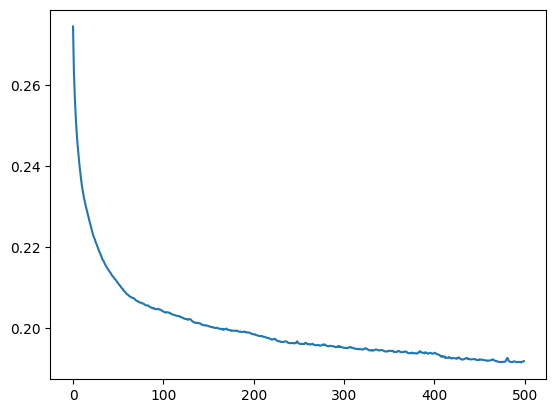

In [27]:
plt.plot(history.history['loss'])